## =========================================================
## 📦 Hopify Product Average Order Value by Segment Plot
## =========================================================

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import matplotlib.dates as mdates

## ================================
## 📁 Set Base Path to Project Root
## ================================

try:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname(__file__), "..", "..", ".."))
except NameError:
    # Jupyter or interactive context
    BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))

print("📁 Base path set to:", BASE_PATH)

## ==================================================
## 📥 Load Data
## ==================================================

In [2]:
file_path = os.path.join(
    BASE_PATH,
    "01_project_artifacts",
    "02_sql_output",
    "03_project_product_cust_behavior_insights",
    "04_hopify_aov_seg_prod_cat.csv"
)

df = pd.read_csv(file_path)

## ================================
## 🧼 Clean Columns
## ================================

In [3]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.rename(columns={
    'segment': 'segment',
    'product_category': 'product_category',
    'average_order_value_(aov)': 'aov'
}, inplace=True)

# Format segment names
df['segment'] = df['segment'].str.title().replace("Smb", "SMB")

## ==================================================
## 🎨 Plot
## ==================================================

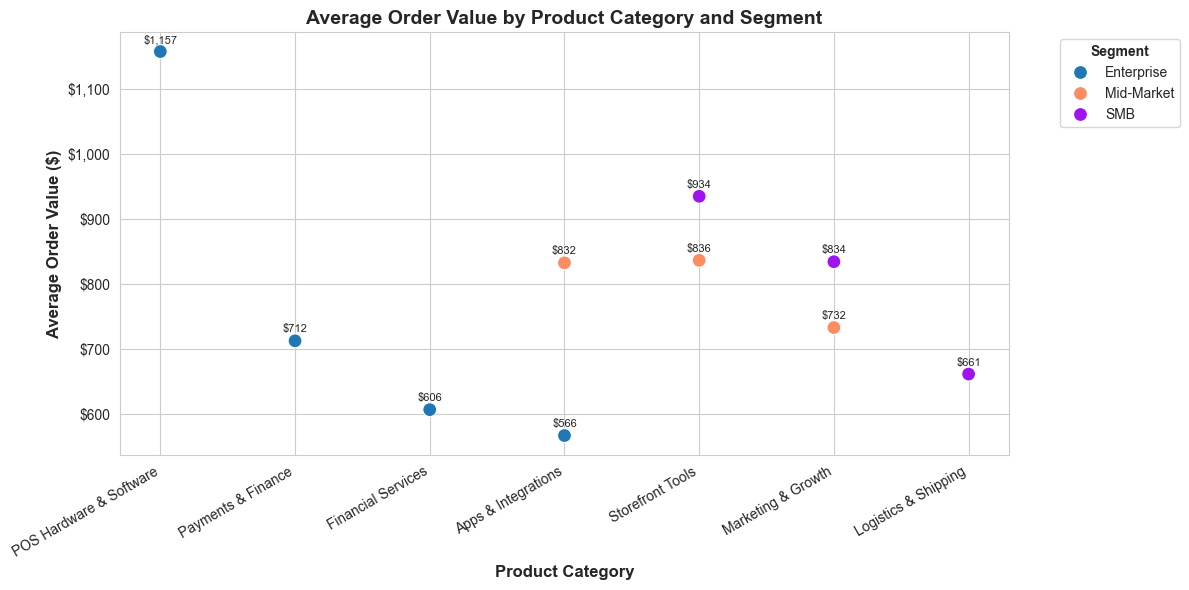

In [4]:
custom_palette = {
    "Enterprise": "#1f77b4",
    "Mid-Market": "#fc8d62",
    "SMB": "#9f13ef"
}

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Create scatterplot
ax = sns.scatterplot(
    data=df,
    x="product_category",
    y="aov",
    hue="segment",
    palette=custom_palette,
    s=100,
    legend="full"
)

# Format y-axis
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Annotate points
for _, row in df.iterrows():
    plt.text(
        x=row["product_category"],
        y=row["aov"] + 10,
        s=f"${int(row['aov']):,}",
        ha='center',
        va='bottom',
        fontsize=8
    )

# Titles and labels
plt.title("Average Order Value by Product Category and Segment", fontsize=14, fontweight='bold')
plt.xlabel("Product Category", fontsize=12, fontweight='bold')
plt.ylabel("Average Order Value ($)", fontsize=12, fontweight='bold')
plt.xticks(rotation=30, ha='right')

# Format legend
legend = plt.legend(title="Segment", bbox_to_anchor=(1.05, 1), loc="upper left")
legend.get_title().set_fontweight('bold')

plt.tight_layout()

## ================================
## 💾 Save & Show
## ================================

In [5]:
output_path = os.path.join(
    BASE_PATH,
    "05_visuals",
    "03_project_product_cust_behavior_insights",
    "hopify_prod_aov_by_seg.png"
)
plt.savefig(output_path, dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>